In [5]:
# -------------------------------
# STEP 1: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer


In [6]:
# -------------------------------
# STEP 2: Load Data

df = pd.read_csv("loan.csv")  # Replace with your actual file


In [7]:
# -------------------------------
# STEP 3: Feature Engineering

df['income_to_expense_ratio'] = df['annual_income'] / (df['monthly_expenses'] * 12 + 1)
df['dependents'] = df['old_dependents'] + df['young_dependents']
df.drop(columns=['old_dependents', 'young_dependents'], inplace=True)

# Drop weak features (if they exist)
weak_features = ['sex', 'home_ownership', 'type_of_house', 'water_availabity', 'Id']
df = df.drop(columns=[col for col in weak_features if col in df.columns])


In [8]:
# -------------------------------
# STEP 4: Preprocessing

# Separate features and target
X = df.drop(columns=['loan_amount'])
y = df['loan_amount']

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include='object').columns

# Handle missing values
X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Scale numeric features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_encoded)


In [9]:
# -------------------------------
# STEP 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=123
)


In [10]:
# -------------------------------
# STEP 6: Train Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [11]:
# -------------------------------
# STEP 7: Evaluate the Model

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("✅ Random Forest Evaluation")
print(f"MAE: ₹{mae:.2f}")
print(f"MSE: ₹{mse:.2f}")
print(f"R² Score: {r2:.4f}")


✅ Random Forest Evaluation
MAE: ₹1331.88
MSE: ₹80169002.01
R² Score: 0.6669


In [12]:
# -------------------------------
# STEP 8: Save the Model

joblib.dump(rf, 'loan_amount_rf_model.pkl')
print("✅ Model saved as 'loan_amount_rf_model.pkl'")


✅ Model saved as 'loan_amount_rf_model.pkl'


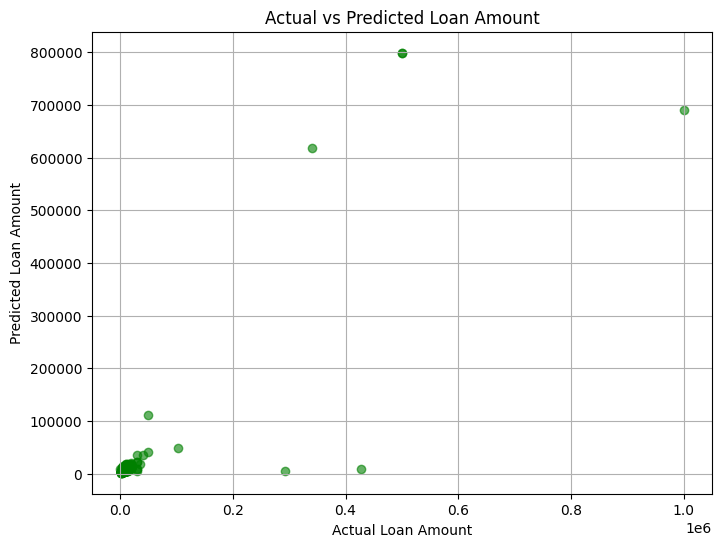

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")
plt.grid(True)
plt.show()
